# Modelagem - Classificação

## Tech Challenge Fase 3 - Machine Learning Engineering

**Objetivo:** Treinar e avaliar modelos de classificação para prever atrasos de voos.

### Targets:
- **IS_DELAYED** → Classificação binária (atraso ≥ 15 min)
- **DELAY_SEVERITY_ENCODED** → Classificação multiclasse (5 categorias)

### Estrutura:
1. Configuração e Imports
2. Carregamento dos Dados
3. Análise Exploratória dos Splits
4. Tratamento de Desbalanceamento
5. Modelos de Classificação Binária
6. Comparação de Modelos
7. Tuning do Melhor Modelo
8. Avaliação Final (Test Set)
9. Importância das Features
10. Classificação Multiclasse
11. Salvamento dos Modelos
12. Resumo Final

In [10]:
# =============================================================================
# 1. CONFIGURAÇÃO E IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

# Sklearn - pré-processamento e divisão
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Sklearn - modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier

# Sklearn - métricas
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, average_precision_score, precision_recall_curve,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

# Sklearn - tuning e validação
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold

# Imbalanced-learn - tratamento de desbalanceamento
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
    print('✅ imbalanced-learn disponível')
except ImportError:
    SMOTE_AVAILABLE = False
    print('⚠️  imbalanced-learn não instalado — usaremos class_weight')

# XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('✅ XGBoost disponível')
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  XGBoost não instalado — será pulado')

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

# ⚙️  CONFIGURAÇÃO: defina True para usar GPU no XGBoost (requer CUDA)
USE_GPU = True

# Monta parâmetros de device para XGBoost
if USE_GPU and XGB_AVAILABLE:
    XGB_DEVICE_PARAMS = {
        'device': 'cuda',
        'tree_method': 'hist'
    }
    print(f'✅ XGBoost GPU ativado (CUDA)')
else:
    XGB_DEVICE_PARAMS = {
        'n_jobs': -1
    }
    if XGB_AVAILABLE:
        print('ℹ️  XGBoost rodando em CPU (USE_GPU=False)')

print('\n✅ Bibliotecas carregadas com sucesso!')

✅ imbalanced-learn disponível
✅ XGBoost disponível
✅ XGBoost GPU ativado (CUDA)

✅ Bibliotecas carregadas com sucesso!


---
## 2. Carregamento dos Dados

Carregamos os datasets de treino e teste gerados pelo notebook de Feature Engineering, juntamente com os metadados e encoders.

In [2]:
# =============================================================================
# CARREGA DADOS DE TREINO E TESTE
# =============================================================================
train_df = pd.read_parquet('../data/processed/train_classification.parquet')
test_df  = pd.read_parquet('../data/processed/test_classification.parquet')

print(f'📊 Train: {train_df.shape[0]:,} linhas × {train_df.shape[1]} colunas')
print(f'📊 Test:  {test_df.shape[0]:,} linhas × {test_df.shape[1]} colunas')

# Carrega metadados do Feature Engineering
metadata = joblib.load('../models/feature_engineering_metadata.pkl')
encoders = joblib.load('../models/feature_encoders.pkl')

features = metadata['features_classification']
target   = metadata['target_classification']      # IS_DELAYED
target_mc = metadata['target_multiclass']          # DELAY_SEVERITY_ENCODED

print(f'\n📋 Features para classificação: {len(features)}')
print(f'🎯 Target binário: {target}')
print(f'🎯 Target multiclasse: {target_mc}')

# Separa X e y
X_train = train_df[features]
y_train = train_df[target]

X_test  = test_df[features]
y_test  = test_df[target]

y_train_mc = train_df[target_mc]
y_test_mc  = test_df[target_mc]

print(f'\n✅ X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'✅ X_test:  {X_test.shape}  | y_test:  {y_test.shape}')

📊 Train: 4,571,206 linhas × 30 colunas
📊 Test:  1,142,802 linhas × 30 colunas

📋 Features para classificação: 28
🎯 Target binário: IS_DELAYED
🎯 Target multiclasse: DELAY_SEVERITY_ENCODED

✅ X_train: (4571206, 28) | y_train: (4571206,)
✅ X_test:  (1142802, 28)  | y_test:  (1142802,)


---
## 3. Análise Exploratória dos Splits

Verificamos a distribuição de classes e estatísticas básicas dos conjuntos de treino e teste.

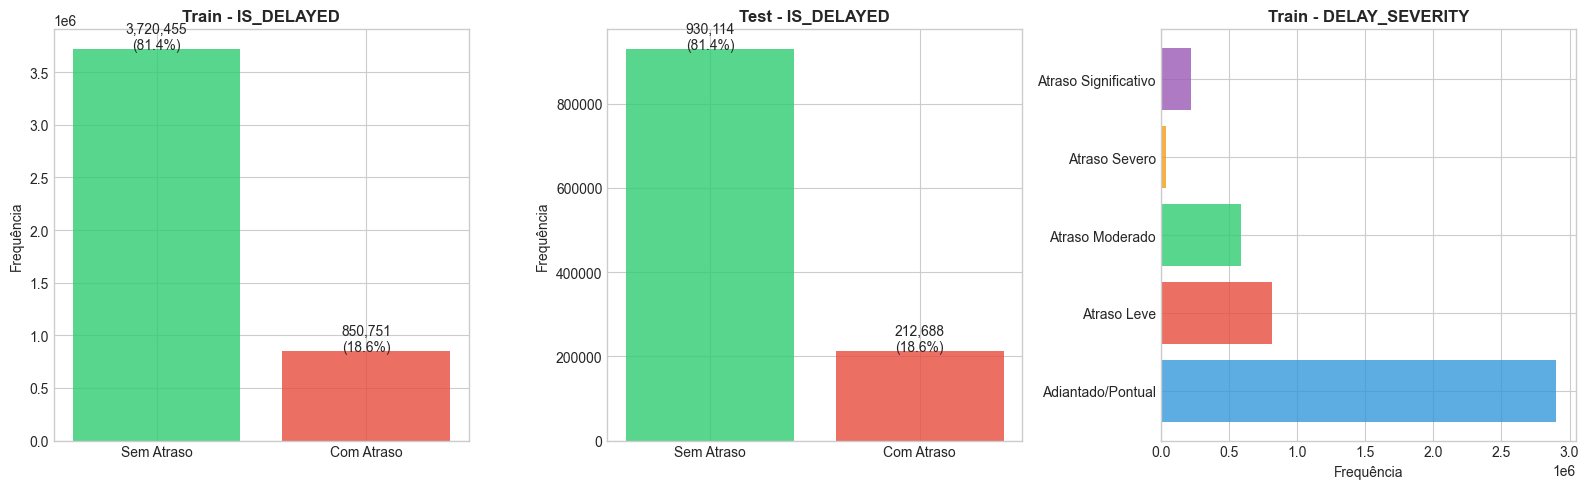


📊 Razão de desbalanceamento (treino): 4.37:1
   Classe majoritária (0 - Sem Atraso): 3,720,455
   Classe minoritária (1 - Com Atraso): 850,751


In [3]:
# =============================================================================
# DISTRIBUIÇÃO DE CLASSES
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Train - IS_DELAYED
ax1 = axes[0]
counts_train = y_train.value_counts().sort_index()
bars = ax1.bar(['Sem Atraso', 'Com Atraso'], counts_train.values, color=[COLORS[2], COLORS[1]], alpha=0.8)
for bar, val in zip(bars, counts_train.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val:,}\n({val/len(y_train)*100:.1f}%)', ha='center', fontsize=10)
ax1.set_title('Train - IS_DELAYED', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequência')

# Test - IS_DELAYED
ax2 = axes[1]
counts_test = y_test.value_counts().sort_index()
bars = ax2.bar(['Sem Atraso', 'Com Atraso'], counts_test.values, color=[COLORS[2], COLORS[1]], alpha=0.8)
for bar, val in zip(bars, counts_test.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}\n({val/len(y_test)*100:.1f}%)', ha='center', fontsize=10)
ax2.set_title('Test - IS_DELAYED', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequência')

# Train - DELAY_SEVERITY
ax3 = axes[2]
severity_labels = {v: k for k, v in zip(encoders['delay_severity'].classes_,
                                         encoders['delay_severity'].transform(encoders['delay_severity'].classes_))}
counts_mc = y_train_mc.value_counts().sort_index()
labels_mc = [severity_labels.get(i, str(i)) for i in counts_mc.index]
ax3.barh(labels_mc, counts_mc.values, color=COLORS[:len(labels_mc)], alpha=0.8)
ax3.set_title('Train - DELAY_SEVERITY', fontsize=12, fontweight='bold')
ax3.set_xlabel('Frequência')

plt.tight_layout()
plt.savefig('../data/processed/fig_clf_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Razão de desbalanceamento
ratio = counts_train[0] / counts_train[1]
print(f'\n📊 Razão de desbalanceamento (treino): {ratio:.2f}:1')
print(f'   Classe majoritária (0 - Sem Atraso): {counts_train[0]:,}')
print(f'   Classe minoritária (1 - Com Atraso): {counts_train[1]:,}')

---
## 4. Tratamento de Desbalanceamento

O dataset apresenta desbalanceamento entre classes. Usaremos duas estratégias:
- **Estratégia A:** `class_weight='balanced'` (incorporado nos modelos sklearn)
- **Estratégia B:** SMOTE (Synthetic Minority Oversampling)

In [4]:
# =============================================================================
# APLICAÇÃO DE SMOTE (se disponível) OU USO DE class_weight
# =============================================================================

# ⚙️  CONFIGURAÇÃO: defina True para aplicar SMOTE, False para usar class_weight
USE_SMOTE = False

if USE_SMOTE and SMOTE_AVAILABLE:
    smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.5)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    print(f'✅ SMOTE aplicado:')
    print(f'   Antes:  {len(y_train):,} ({y_train.mean()*100:.1f}% positivos)')
    print(f'   Depois: {len(y_train_resampled):,} ({y_train_resampled.mean()*100:.1f}% positivos)')
elif USE_SMOTE and not SMOTE_AVAILABLE:
    X_train_resampled = X_train.copy()
    y_train_resampled = y_train.copy()
    print('⚠️  USE_SMOTE=True, mas imbalanced-learn não está instalado.')
    print('   Fallback: usando class_weight="balanced" nos modelos.')
else:
    X_train_resampled = X_train.copy()
    y_train_resampled = y_train.copy()
    print('ℹ️  USE_SMOTE=False — usando class_weight="balanced" nos modelos.')

# Razão após balanceamento
pos = y_train_resampled.sum()
neg = len(y_train_resampled) - pos
print(f'\n📊 Distribuição após tratamento:')
print(f'   Classe 0: {neg:,} ({neg/len(y_train_resampled)*100:.1f}%)')
print(f'   Classe 1: {pos:,} ({pos/len(y_train_resampled)*100:.1f}%)')

ℹ️  USE_SMOTE=False — usando class_weight="balanced" nos modelos.

📊 Distribuição após tratamento:
   Classe 0: 3,720,455 (81.4%)
   Classe 1: 850,751 (18.6%)


---
## 5. Modelos de Classificação Binária

Treinamos quatro modelos em ordem crescente de complexidade:
1. **DummyClassifier** — baseline ingênua
2. **Logistic Regression** — baseline linear
3. **Random Forest** — ensemble de árvores
4. **XGBoost** / **Gradient Boosting** — boosting

In [5]:
# =============================================================================
# FUNÇÕES AUXILIARES DE AVALIAÇÃO
# =============================================================================

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, verbose=True):
    """Treina e avalia um modelo, retorna dict com métricas."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc   = accuracy_score(y_te, y_pred)
    f1    = f1_score(y_te, y_pred, zero_division=0)
    roc   = roc_auc_score(y_te, y_prob) if y_prob is not None else None
    ap    = average_precision_score(y_te, y_prob) if y_prob is not None else None

    if verbose:
        print(f'\n{"="*55}')
        print(f'  {name}')
        print(f'{"="*55}')
        print(f'  Accuracy  : {acc:.4f}')
        print(f'  F1 Score  : {f1:.4f}')
        print(f'  ROC-AUC   : {roc:.4f}' if roc else '  ROC-AUC   : N/A')
        print(f'  Avg Prec. : {ap:.4f}' if ap else '  Avg Prec. : N/A')
        print(classification_report(y_te, y_pred, target_names=['Sem Atraso', 'Com Atraso']))

    return {
        'name': name, 'model': model,
        'accuracy': acc, 'f1': f1,
        'roc_auc': roc, 'avg_precision': ap,
        'y_pred': y_pred, 'y_prob': y_prob
    }

results = {}
print('✅ Funções auxiliares definidas')

✅ Funções auxiliares definidas


In [6]:
# =============================================================================
# MODELO 1 — BASELINE (DummyClassifier)
# =============================================================================
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
results['Dummy'] = evaluate_model('Baseline (Dummy)', dummy, X_train, y_train, X_test, y_test)


  Baseline (Dummy)
  Accuracy  : 0.6976
  F1 Score  : 0.1878
  ROC-AUC   : 0.5010
  Avg Prec. : 0.1864
              precision    recall  f1-score   support

  Sem Atraso       0.81      0.81      0.81    930114
  Com Atraso       0.19      0.19      0.19    212688

    accuracy                           0.70   1142802
   macro avg       0.50      0.50      0.50   1142802
weighted avg       0.70      0.70      0.70   1142802



In [7]:
# =============================================================================
# MODELO 2 — LOGISTIC REGRESSION (baseline linear)
# =============================================================================
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])
results['LR'] = evaluate_model('Logistic Regression', lr_pipe, X_train_resampled, y_train_resampled, X_test, y_test)


  Logistic Regression
  Accuracy  : 0.5861
  F1 Score  : 0.3656
  ROC-AUC   : 0.6456
  Avg Prec. : 0.2777
              precision    recall  f1-score   support

  Sem Atraso       0.87      0.57      0.69    930114
  Com Atraso       0.26      0.64      0.37    212688

    accuracy                           0.59   1142802
   macro avg       0.57      0.61      0.53   1142802
weighted avg       0.76      0.59      0.63   1142802



In [8]:
# =============================================================================
# MODELO 3 — RANDOM FOREST
# =============================================================================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
results['RF'] = evaluate_model('Random Forest', rf, X_train_resampled, y_train_resampled, X_test, y_test)


  Random Forest
  Accuracy  : 0.6109
  F1 Score  : 0.3856
  ROC-AUC   : 0.6788
  Avg Prec. : 0.3211
              precision    recall  f1-score   support

  Sem Atraso       0.88      0.60      0.72    930114
  Com Atraso       0.27      0.66      0.39    212688

    accuracy                           0.61   1142802
   macro avg       0.58      0.63      0.55   1142802
weighted avg       0.77      0.61      0.65   1142802



In [11]:
# =============================================================================
# MODELO 4 — XGBOOST (ou Gradient Boosting como fallback)
# =============================================================================
if XGB_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    booster = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        **XGB_DEVICE_PARAMS
    )
    results['XGB'] = evaluate_model('XGBoost', booster, X_train_resampled, y_train_resampled, X_test, y_test)
else:
    gbt = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=RANDOM_STATE
    )
    results['GBT'] = evaluate_model('Gradient Boosting', gbt, X_train_resampled, y_train_resampled, X_test, y_test)


  XGBoost
  Accuracy  : 0.6300
  F1 Score  : 0.3973
  ROC-AUC   : 0.6934
  Avg Prec. : 0.3431
              precision    recall  f1-score   support

  Sem Atraso       0.89      0.62      0.73    930114
  Com Atraso       0.29      0.66      0.40    212688

    accuracy                           0.63   1142802
   macro avg       0.59      0.64      0.57   1142802
weighted avg       0.78      0.63      0.67   1142802



---
## 6. Comparação de Modelos

Visualizamos as métricas de todos os modelos treinados para identificar o melhor candidato ao tuning.

In [12]:
# =============================================================================
# TABELA DE COMPARAÇÃO DE MÉTRICAS
# =============================================================================
metrics_df = pd.DataFrame([
    {
        'Modelo': r['name'],
        'Accuracy': r['accuracy'],
        'F1': r['f1'],
        'ROC-AUC': r['roc_auc'],
        'Avg Precision': r['avg_precision']
    }
    for r in results.values()
]).sort_values('ROC-AUC', ascending=False)

print('📊 COMPARAÇÃO DE MODELOS (ordenado por ROC-AUC)')
print(metrics_df.to_string(index=False))

# Identifica melhor modelo
best_key = max(results, key=lambda k: results[k]['roc_auc'] or 0)
print(f'\n🏆 Melhor modelo: {results[best_key]["name"]} (ROC-AUC={results[best_key]["roc_auc"]:.4f})')

📊 COMPARAÇÃO DE MODELOS (ordenado por ROC-AUC)
             Modelo  Accuracy     F1  ROC-AUC  Avg Precision
            XGBoost    0.6300 0.3973   0.6934         0.3431
      Random Forest    0.6109 0.3856   0.6788         0.3211
Logistic Regression    0.5861 0.3656   0.6456         0.2777
   Baseline (Dummy)    0.6976 0.1878   0.5010         0.1864

🏆 Melhor modelo: XGBoost (ROC-AUC=0.6934)


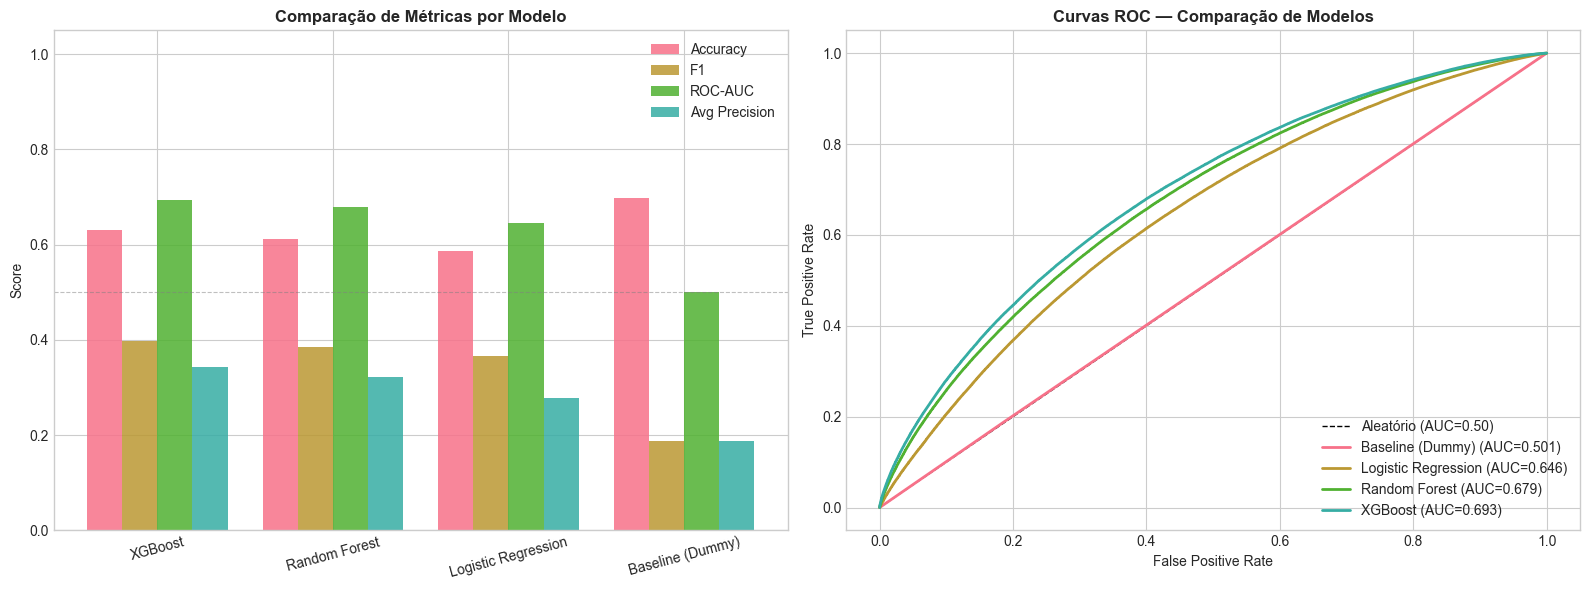

✅ Figura salva: fig_clf_02_model_comparison.png


In [13]:
# =============================================================================
# GRÁFICO DE BARRAS DE MÉTRICAS + CURVAS ROC
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Barras de métricas ---
ax1 = axes[0]
metric_cols = ['Accuracy', 'F1', 'ROC-AUC', 'Avg Precision']
x = np.arange(len(metrics_df))
width = 0.2
for i, col in enumerate(metric_cols):
    ax1.bar(x + i * width, metrics_df[col], width, label=col, alpha=0.85)
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(metrics_df['Modelo'], rotation=15)
ax1.set_ylim(0, 1.05)
ax1.set_title('Comparação de Métricas por Modelo', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score')
ax1.legend(loc='upper right')
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# --- Curvas ROC ---
ax2 = axes[1]
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC=0.50)')
for key, r in results.items():
    if r['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
        ax2.plot(fpr, tpr, label=f'{r["name"]} (AUC={r["roc_auc"]:.3f})', linewidth=2)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Curvas ROC — Comparação de Modelos', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../data/processed/fig_clf_02_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: fig_clf_02_model_comparison.png')

---
## 7. Tuning do Melhor Modelo

Aplicamos `RandomizedSearchCV` com validação cruzada estratificada no modelo que obteve melhor ROC-AUC.

In [15]:
# =============================================================================
# RANDOMIZED SEARCH CV — RANDOM FOREST (ou XGBoost se disponível)
# =============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if XGB_AVAILABLE:
    param_dist = {
        'n_estimators':     [200, 300, 500, 700],
        'max_depth':        [4, 6, 8, 10],
        'learning_rate':    [0.05, 0.1, 0.2, 0.3],
        'subsample':        [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9, 1],
        'min_child_weight': [1, 3, 5],
    }
    scale_pw = (y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()
    base_clf = xgb.XGBClassifier(
        scale_pos_weight=scale_pw, eval_metric='logloss',
        use_label_encoder=False, random_state=RANDOM_STATE,
        **XGB_DEVICE_PARAMS
    )
    tuning_name = 'XGBoost (Tuned)'
else:
    param_dist = {
        'n_estimators':  [200, 300, 500],
        'max_depth':     [8, 12, 16, None],
        'min_samples_leaf': [20, 50, 100],
        'max_features':  ['sqrt', 'log2', 0.3],
    }
    base_clf = RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    tuning_name = 'Random Forest (Tuned)'

search = RandomizedSearchCV(
    base_clf, param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=1
)

print(f'🔍 Iniciando RandomizedSearchCV para {tuning_name}...')
search.fit(X_train_resampled, y_train_resampled)
print(f'\n✅ Melhor ROC-AUC CV: {search.best_score_:.4f}')
print(f'   Melhores parâmetros: {search.best_params_}')

🔍 Iniciando RandomizedSearchCV para XGBoost (Tuned)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Melhor ROC-AUC CV: 0.7118
   Melhores parâmetros: {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [16]:
# Avalia modelo tunado no test set
results['Tuned'] = evaluate_model(
    tuning_name,
    search.best_estimator_,
    X_train_resampled, y_train_resampled,
    X_test, y_test
)

# Atualiza tabela de comparação
metrics_df = pd.DataFrame([
    {
        'Modelo': r['name'],
        'Accuracy': r['accuracy'],
        'F1': r['f1'],
        'ROC-AUC': r['roc_auc'],
        'Avg Precision': r['avg_precision']
    }
    for r in results.values()
]).sort_values('ROC-AUC', ascending=False)

print('\n📊 COMPARAÇÃO ATUALIZADA (com modelo tunado):')
print(metrics_df.to_string(index=False))

# Define modelo final
final_model = search.best_estimator_
print(f'\n🏆 Modelo final selecionado: {tuning_name}')


  XGBoost (Tuned)
  Accuracy  : 0.6593
  F1 Score  : 0.4147
  ROC-AUC   : 0.7134
  Avg Prec. : 0.3716
              precision    recall  f1-score   support

  Sem Atraso       0.89      0.66      0.76    930114
  Com Atraso       0.30      0.65      0.41    212688

    accuracy                           0.66   1142802
   macro avg       0.60      0.66      0.59   1142802
weighted avg       0.78      0.66      0.70   1142802


📊 COMPARAÇÃO ATUALIZADA (com modelo tunado):
             Modelo  Accuracy     F1  ROC-AUC  Avg Precision
    XGBoost (Tuned)    0.6593 0.4147   0.7134         0.3716
            XGBoost    0.6300 0.3973   0.6934         0.3431
      Random Forest    0.6109 0.3856   0.6788         0.3211
Logistic Regression    0.5861 0.3656   0.6456         0.2777
   Baseline (Dummy)    0.6976 0.1878   0.5010         0.1864

🏆 Modelo final selecionado: XGBoost (Tuned)


---
## 8. Avaliação Final no Test Set

Análise detalhada do modelo final: Matriz de Confusão, Curva ROC e Curva Precision-Recall.

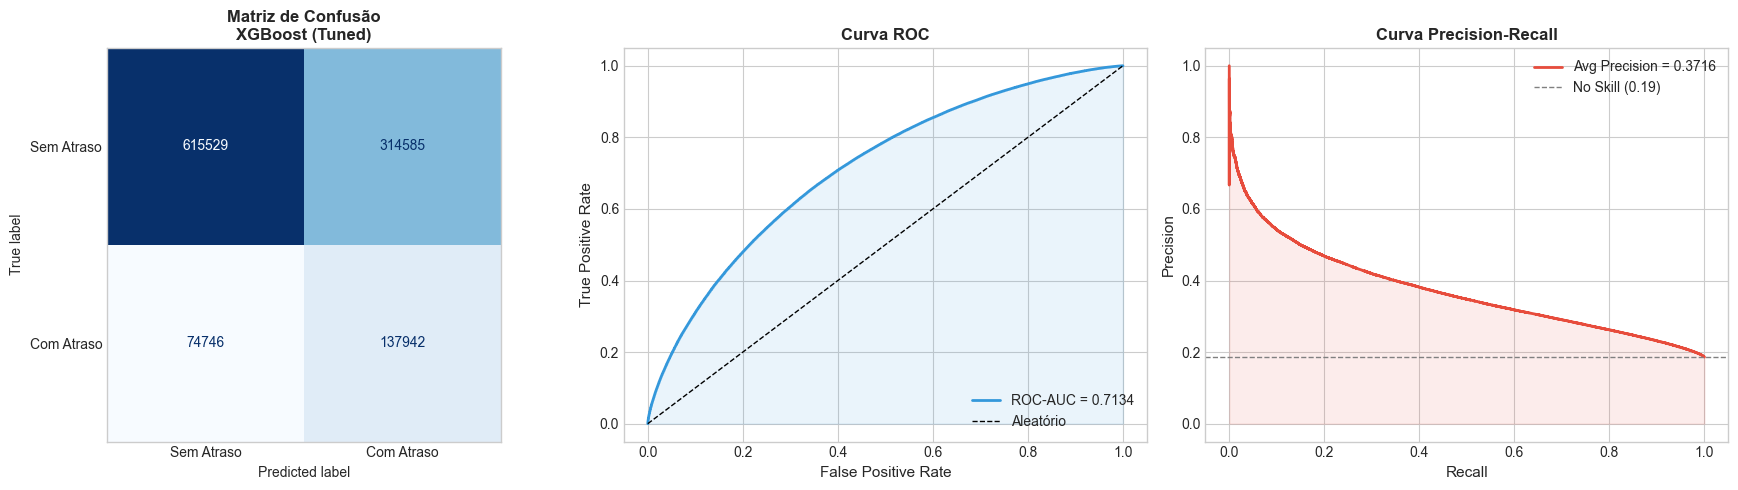

✅ Figura salva: fig_clf_03_final_evaluation.png

📊 MÉTRICAS DETALHADAS — XGBoost (Tuned):
   TP=137,942  FP=314,585  FN=74,746  TN=615,529
   Precision (+ class): 0.3048
   Recall    (+ class): 0.6486
   F1 Score  (+ class): 0.4147
   ROC-AUC            : 0.7134


In [18]:

# =============================================================================
# AVALIAÇÃO DETALHADA DO MODELO FINAL
# =============================================================================
tuned_result = results['Tuned']
y_pred_final = tuned_result['y_pred']
y_prob_final = tuned_result['y_prob']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de Confusão
ax1 = axes[0]
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem Atraso', 'Com Atraso'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.grid(False)
ax1.set_title(f'Matriz de Confusão\n{tuning_name}', fontsize=12, fontweight='bold')

# 2. Curva ROC
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
ax2.plot(fpr, tpr, color=COLORS[0], linewidth=2,
         label=f'ROC-AUC = {tuned_result["roc_auc"]:.4f}')
ax2.fill_between(fpr, tpr, alpha=0.1, color=COLORS[0])
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('Curva ROC', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')

# 3. Curva Precision-Recall
ax3 = axes[2]
precision, recall, _ = precision_recall_curve(y_test, y_prob_final)
ap = tuned_result['avg_precision']
ax3.plot(recall, precision, color=COLORS[1], linewidth=2,
         label=f'Avg Precision = {ap:.4f}')
ax3.fill_between(recall, precision, alpha=0.1, color=COLORS[1])
no_skill = y_test.mean()
ax3.axhline(no_skill, color='gray', linestyle='--', linewidth=1, label=f'No Skill ({no_skill:.2f})')
ax3.set_xlabel('Recall', fontsize=11)
ax3.set_ylabel('Precision', fontsize=11)
ax3.set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../data/processed/fig_clf_03_final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: fig_clf_03_final_evaluation.png')

# Resumo de métricas
tn, fp, fn, tp = cm.ravel()
print(f'\n📊 MÉTRICAS DETALHADAS — {tuning_name}:')
print(f'   TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')
print(f'   Precision (+ class): {tp/(tp+fp):.4f}')
print(f'   Recall    (+ class): {tp/(tp+fn):.4f}')
print(f'   F1 Score  (+ class): {tuned_result["f1"]:.4f}')
print(f'   ROC-AUC            : {tuned_result["roc_auc"]:.4f}')


---
## 9. Importância das Features

Analisamos quais features mais contribuíram para as previsões do modelo final.

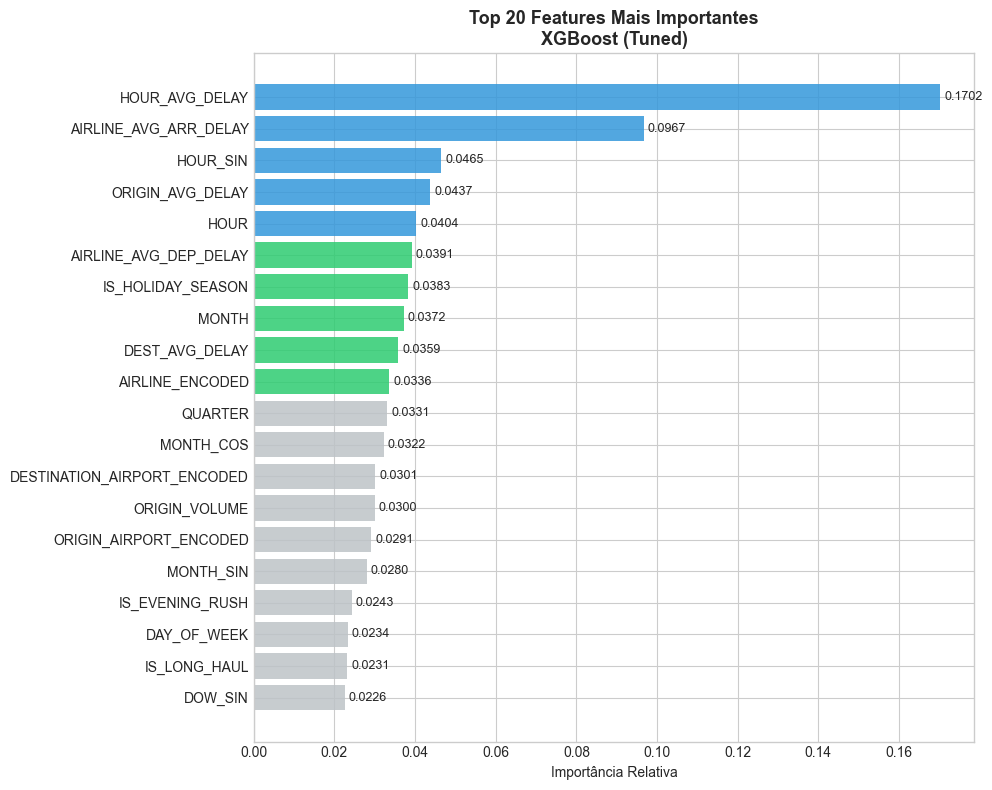

✅ Figura salva: fig_clf_04_feature_importance.png

📊 Top 10 features:
              Feature  Importance
       HOUR_AVG_DELAY      0.1702
AIRLINE_AVG_ARR_DELAY      0.0967
             HOUR_SIN      0.0465
     ORIGIN_AVG_DELAY      0.0437
                 HOUR      0.0404
AIRLINE_AVG_DEP_DELAY      0.0391
    IS_HOLIDAY_SEASON      0.0383
                MONTH      0.0372
       DEST_AVG_DELAY      0.0359
      AIRLINE_ENCODED      0.0336


In [19]:
# =============================================================================
# FEATURE IMPORTANCE
# =============================================================================

# Extraímos importâncias (funciona para RF e XGB)
clf_for_importance = final_model
if hasattr(clf_for_importance, 'named_steps'):
    clf_for_importance = clf_for_importance.named_steps.get('model', clf_for_importance)

if hasattr(clf_for_importance, 'feature_importances_'):
    importances = clf_for_importance.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Top 20 features
    top20 = feat_imp_df.head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_imp = [COLORS[0] if i < 5 else COLORS[2] if i < 10 else '#bdc3c7' for i in range(len(top20))]
    ax.barh(top20['Feature'][::-1], top20['Importance'][::-1], color=colors_imp[::-1], alpha=0.85)
    ax.set_title(f'Top 20 Features Mais Importantes\n{tuning_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importância Relativa')
    for i, (val, feat) in enumerate(zip(top20['Importance'][::-1], top20['Feature'][::-1])):
        ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../data/processed/fig_clf_04_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Figura salva: fig_clf_04_feature_importance.png')
    print(f'\n📊 Top 10 features:\n{feat_imp_df.head(10).to_string(index=False)}')
else:
    print('⚠️  Modelo não suporta feature_importances_ diretamente.')

---
## 10. Classificação Multiclasse — DELAY_SEVERITY

Treinamos um modelo para prever a **severidade do atraso** em 5 categorias:
Adiantado/Pontual · Atraso Leve · Atraso Moderado · Atraso Significativo · Atraso Severo

📊 RELATÓRIO — DELAY_SEVERITY (Multiclasse):
                      precision    recall  f1-score   support

   Adiantado/Pontual       0.63      1.00      0.78    725423
         Atraso Leve       0.00      0.00      0.00    204691
     Atraso Moderado       0.50      0.00      0.00    147570
       Atraso Severo       0.00      0.00      0.00      9572
Atraso Significativo       0.00      0.00      0.00     55546

            accuracy                           0.63   1142802
           macro avg       0.23      0.20      0.16   1142802
        weighted avg       0.47      0.63      0.49   1142802



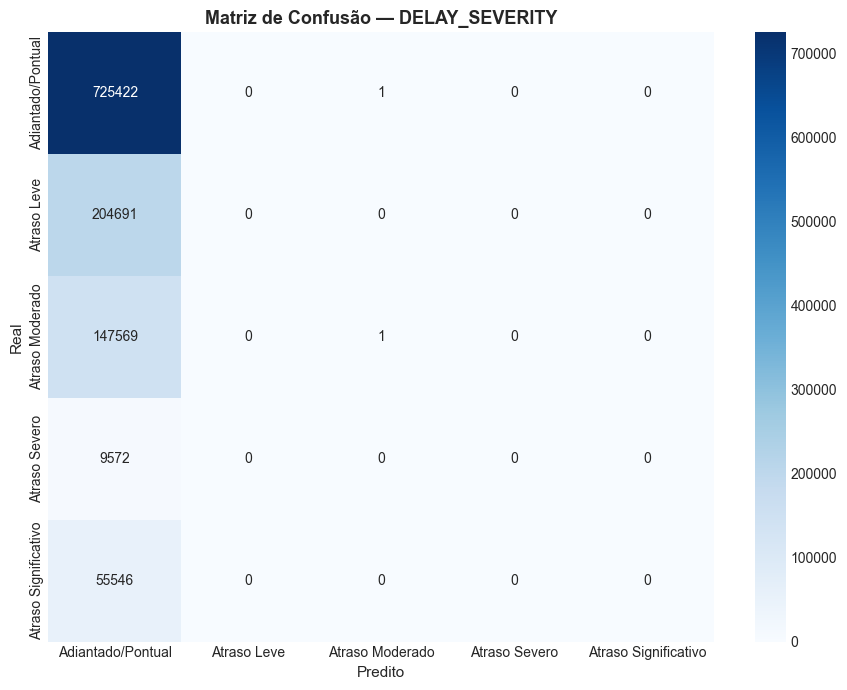

✅ Figura salva: fig_clf_05_multiclass_cm.png

🎯 F1 Macro (Multiclasse): 0.1553


In [22]:

# =============================================================================
# TREINO DO MODELO MULTICLASSE
# =============================================================================

if XGB_AVAILABLE:
    mc_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        **XGB_DEVICE_PARAMS
    )
else:
    mc_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

mc_model.fit(X_train_resampled if SMOTE_AVAILABLE else X_train, y_train_mc)
y_pred_mc = mc_model.predict(X_test)

# Labels das classes — filtra apenas as classes presentes nos dados
labels_present = sorted(set(y_test_mc) | set(y_pred_mc))
class_names = encoders['delay_severity'].classes_[labels_present]

print('📊 RELATÓRIO — DELAY_SEVERITY (Multiclasse):')
print(classification_report(y_test_mc, y_pred_mc, labels=labels_present, target_names=class_names, zero_division=0))

# Matriz de confusão multiclasse
fig, ax = plt.subplots(figsize=(9, 7))
cm_mc = confusion_matrix(y_test_mc, y_pred_mc, labels=labels_present)
sns.heatmap(cm_mc, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel('Predito', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title('Matriz de Confusão — DELAY_SEVERITY', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_clf_05_multiclass_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: fig_clf_05_multiclass_cm.png')

# F1 macro
f1_mc = f1_score(y_test_mc, y_pred_mc, average='macro', zero_division=0)
print(f'\n🎯 F1 Macro (Multiclasse): {f1_mc:.4f}')


---
## 11. Salvamento dos Modelos

Persistimos o modelo final (binário e multiclasse) e os metadados de avaliação para uso em produção.

In [23]:
# =============================================================================
# SALVAMENTO DOS MODELOS E METADADOS
# =============================================================================
os.makedirs('../models/supervised', exist_ok=True)

# 1. Modelo binário final
joblib.dump(final_model, '../models/supervised/clf_binary_final.joblib')
print('✅ Modelo binário salvo: models/supervised/clf_binary_final.joblib')

# 2. Modelo multiclasse
joblib.dump(mc_model, '../models/supervised/clf_multiclass_final.joblib')
print('✅ Modelo multiclasse salvo: models/supervised/clf_multiclass_final.joblib')

# 3. Metadados de classificação
clf_metadata = {
    'model_name': tuning_name,
    'features': features,
    'target_binary': target,
    'target_multiclass': target_mc,
    'best_params': search.best_params_,
    'cv_roc_auc': search.best_score_,
    'test_metrics': {
        'accuracy': tuned_result['accuracy'],
        'f1': tuned_result['f1'],
        'roc_auc': tuned_result['roc_auc'],
        'avg_precision': tuned_result['avg_precision']
    },
    'multiclass_f1_macro': f1_mc,
    'class_names': list(class_names),
    'delay_threshold': metadata['delay_threshold'],
    'random_state': RANDOM_STATE
}
joblib.dump(clf_metadata, '../models/supervised/clf_metadata.joblib')
print('✅ Metadados salvos: models/supervised/clf_metadata.joblib')

print('\n✅ Salvamento concluído!')

✅ Modelo binário salvo: models/supervised/clf_binary_final.joblib
✅ Modelo multiclasse salvo: models/supervised/clf_multiclass_final.joblib
✅ Metadados salvos: models/supervised/clf_metadata.joblib

✅ Salvamento concluído!


---
## 12. Resumo Final

In [24]:
# =============================================================================
# RESUMO DO NOTEBOOK
# =============================================================================
print('📊 RESUMO — MODELAGEM DE CLASSIFICAÇÃO')
print('=' * 65)

print(f'\n🔹 DADOS UTILIZADOS:')
print(f'   Train: {len(X_train):,} registros | Test: {len(X_test):,} registros')
print(f'   Features: {len(features)}')
print(f'   Desbalanceamento tratado: {"SMOTE" if SMOTE_AVAILABLE else "class_weight=balanced"}')

print(f'\n🔹 MODELOS TREINADOS:')
for r in results.values():
    roc = f'{r["roc_auc"]:.4f}' if r['roc_auc'] else 'N/A'
    print(f'   {r["name"]:<35} ROC-AUC={roc}  F1={r["f1"]:.4f}')

print(f'\n🏆 MODELO FINAL: {tuning_name}')
print(f'   Accuracy      : {tuned_result["accuracy"]:.4f}')
print(f'   F1 (classe +) : {tuned_result["f1"]:.4f}')
print(f'   ROC-AUC       : {tuned_result["roc_auc"]:.4f}')
print(f'   Avg Precision : {tuned_result["avg_precision"]:.4f}')

print(f'\n🔹 CLASSIFICAÇÃO MULTICLASSE (DELAY_SEVERITY):')
print(f'   F1 Macro: {f1_mc:.4f}')

print(f'\n🔹 ARTEFATOS SALVOS:')
print(f'   📁 models/supervised/clf_binary_final.joblib')
print(f'   📁 models/supervised/clf_multiclass_final.joblib')
print(f'   📁 models/supervised/clf_metadata.joblib')

print('\n' + '=' * 65)
print('🎯 PRÓXIMO PASSO: 04_modeling_regression.ipynb')
print('=' * 65)

📊 RESUMO — MODELAGEM DE CLASSIFICAÇÃO

🔹 DADOS UTILIZADOS:
   Train: 4,571,206 registros | Test: 1,142,802 registros
   Features: 28
   Desbalanceamento tratado: SMOTE

🔹 MODELOS TREINADOS:
   Baseline (Dummy)                    ROC-AUC=0.5010  F1=0.1878
   Logistic Regression                 ROC-AUC=0.6456  F1=0.3656
   Random Forest                       ROC-AUC=0.6788  F1=0.3856
   XGBoost                             ROC-AUC=0.6934  F1=0.3973
   XGBoost (Tuned)                     ROC-AUC=0.7134  F1=0.4147

🏆 MODELO FINAL: XGBoost (Tuned)
   Accuracy      : 0.6593
   F1 (classe +) : 0.4147
   ROC-AUC       : 0.7134
   Avg Precision : 0.3716

🔹 CLASSIFICAÇÃO MULTICLASSE (DELAY_SEVERITY):
   F1 Macro: 0.1553

🔹 ARTEFATOS SALVOS:
   📁 models/supervised/clf_binary_final.joblib
   📁 models/supervised/clf_multiclass_final.joblib
   📁 models/supervised/clf_metadata.joblib

🎯 PRÓXIMO PASSO: 04_modeling_regression.ipynb
